# Stage 1 Methodology

### Part A: Constructing a verified solver for the anchor formula

Part A builds a solver for the Köllner–Gardner–Wadee (KGW, 2023) buckling formula and verifies it against Table 1 of that paper. Everything Stage 1 later predicts is defined relative to this solver, so getting it right — and proving it is right — comes first.

**Contents of Part A**
1. Why the solver has to be verified before any modelling
2. The KGW governing equation and its reduction to a scalar equation in the strength reduction factor
3. Why verification uses an *area-invariant* check, and how that check works
4. How the solver itself works
5. The verification result, plots, and conclusions
6. Applying the verified solver to `master.csv` (hand-off to the modelling sections)

## A.1 · Why verify the solver first

Stage 1 predicts the flexural buckling strength as a dimensionless **strength reduction factor** $\chi = N_b/N_y$ (buckling load over squash load $N_y = A f_y$), plotted in $\chi$–$\bar\lambda$ space. Both the inputs and the target of the model are built from the KGW formula:

- the model **features** include the KGW parameters $(\bar\lambda, n, E, f_y)$;
- every candidate **target** — $\chi_{\text{exp}}$ directly, the residual ratio $r = \chi_{\text{exp}}/\chi_{\text{perfect}}$, or a fitted correction — needs a trustworthy $\chi_{\text{perfect}}$ to even be defined.

So before training anything, the KGW formula is implemented as a solver and checked against the paper's own tabulated predictions. The reason this matters: a bug in the solver would be a *physical* error that shifts every feature and target in the same direction. Cross-validation compares the model against those same biased numbers, so it would never reveal the problem. Verification is therefore a required first step, not something the later modelling can catch.

## A.2 · The governing equation and its scalar form

**The anchor equation.** KGW derive the buckling condition of a Ramberg–Osgood column from a total-potential-energy formulation. The result is a single criticality equation (KGW Eq. 16):

$$f(p) = p^{\,n} + C_1\,p + C_2 = 0 .$$

Here $p = P/(EA)$ is the buckling load in dimensionless form (the actual load is $P^{C} = p\,EA$), $n$ is the Ramberg–Osgood hardening exponent, and the two constants hold the material and section properties:

$$C_1 = \frac{1}{(n+1)\,c_1},\quad C_2 = -\frac{c_2}{c_1},\quad c_1 = \frac{n\,\alpha_{\text{RO}}\,E^{\,n}}{(n+1)\,f_y^{\,n}},\quad c_2 = \frac{\pi^2 I_{zz}}{(n+1)\,A L^2},$$

with $\alpha_{\text{RO}} = 0.002$ (the 0.2 % proof strain), $E$ the initial modulus, $f_y$ the 0.2 % proof stress, $I_{zz}$ the weak-axis second moment of area, $A$ the cross-section area and $L$ the (effective) length.

**Goal: rewrite this in terms of strength, not load.** The quantity Stage 1 needs is the strength reduction factor $\chi = P/P_y$, where $P_y = A f_y$ is the squash load. The steps below simply re-express $f(p)=0$ in terms of $\chi$ and the normalized slenderness.

**Step 1 — simplify the constants.** Introduce $\Delta = f_y/E$ and $\bar\lambda^{2} = P_y/P_E$, where $P_E = \pi^2 EI_{zz}/L^2$:

*Constant $C_1$:*
$$C_1 = \frac{1}{(n+1)c_1} = \frac{f_y^{\,n}}{n\,\alpha_{\text{RO}}E^{\,n}} = \frac{\Delta^{\,n}}{n\,\alpha_{\text{RO}}}.$$

*Constant $C_2$:* the group $\pi^2 I_{zz}/(AL^2)$ is exactly the Euler load in dimensionless form, $P_E/(EA)$. Using $\bar\lambda^2 = P_y/P_E$ this equals $\Delta/\bar\lambda^2$, so
$$c_2 = \frac{\Delta}{(n+1)\bar\lambda^2}, \qquad C_2 = -\frac{c_2}{c_1} = -\frac{\Delta^{\,n+1}}{n\,\alpha_{\text{RO}}\,\bar\lambda^2}.$$

**Step 2 — change the unknown from $p$ to $\chi$.** Since $p = P/(EA)$ and $P_y = Af_y$, the load parameter and the strength factor are related by $p = \chi\,(f_y/E) = \chi\Delta$. Substituting $p = \chi\Delta$ into $f(p)=0$, dividing by $\Delta^{\,n}$ and multiplying by $n\alpha_{\text{RO}}/\Delta$, the material ratios collapse and leave:

$$\boxed{\;\chi + k\,\chi^{\,n} = \dfrac{1}{\bar\lambda^{2}}\;}, \qquad k = \frac{n\,\alpha_{\text{RO}}}{\Delta} = n\,\alpha_{\text{RO}}\,\frac{E}{f_y}.$$

This is the equation the solver actually solves. It depends on only $(\bar\lambda, n, E, f_y)$ — the area and length have cancelled, which is exactly what we expect for a *dimensionless* strength factor. Reading it physically: the right-hand side $1/\bar\lambda^2$ is the elastic (Euler) limit, and $k\chi^{\,n}$ is the Ramberg–Osgood material-softening term.

**Imperfections: lower the hardening exponent.** KGW account for geometric imperfections not by scaling $\chi$, but by reducing the hardening exponent from $n$ to $\beta(\bar\lambda)\,n$, with a correction factor $\beta \le 1$ that departs from 1 only beyond a transition slenderness. Carrying $m = \beta n$ through the same algebra gives the general form the solver uses:

$$\chi + k\,\chi^{\,m} = \frac{1}{\bar\lambda^{2}}, \qquad m = \beta n, \quad k = \frac{m\,\alpha_{\text{RO}}}{\Delta}.$$

Setting $\beta = 1$ gives the **perfect** column ($\chi_{\text{perfect}}$); $\beta < 1$ gives the **imperfection-corrected** strength ($\chi_{\text{corrected}}$). One consequence is important for Stage 2: because $\beta$ sits inside the exponent, the real knockdown $\chi_{\text{corrected}}/\chi_{\text{perfect}}$ is *not* equal to $\beta$. Any correction learned later must be put back inside this solve, not multiplied onto $\chi$.

## A.3 · Verifying against Table 1 — why an area-invariant check

KGW Table 1 lists 42 model buckling loads $P_C^{\text{mod}}$ (in kN) across three experimental campaigns. For each row it gives the reference, material grade, hardening exponent $n$, the normalized slenderness $\bar\lambda$ and the load $P_C^{\text{mod}}$ — but **no cross-section area**, and none of the raw geometry ($H$, $B$, $t$, corner radius) needed to compute one.

A first idea is to convert the solver output to kN and compare directly: $P_{\text{solver}} = \chi_{\text{solver}}\,A f_y$ against $P_C^{\text{mod}}$. There are two problems with this.

1. **The area isn't in the table.** Getting it means returning to the three original source papers and re-deriving section properties for every row.
2. **"Area" is not a single, unambiguous number.** KGW's own squash load is $P_y = A f_y$, where they state that $A$ is the gross area *or* an effective area $A_{\text{eff}}$ for Class 4 (locally slender) sections. On top of that, the three source studies each computed section properties under their own conventions — measured versus nominal thickness, how the internal corner radius is treated, and which effective-width rule is used for slender sections. Two reasonable choices for the same nominal section can differ by around a percent, with no bearing on whether the KGW formula or the solver is correct.

So a kN comparison would blend two unknowns into one residual: genuine solver error, and disagreement between whichever area convention we assumed and the one the original study used. If the numbers disagreed, we could not tell which cause was responsible — which defeats the purpose of a solver unit test.

**The fix is to test the solver in a way that removes the area entirely.** That is the area-invariant shape check described next.

## A.4 · How the area-invariant check works

**Group the rows into families.** A *family* is a set of Table 1 rows sharing the same (reference, $f_y$, $n$). Within a family the section and material are fixed and only the length — hence $\bar\lambda$ — changes. So the squash load $P_y = A f_y$ is the **same constant** for every row in the family.

**Form an area-free ratio.** The tabulated model load is $P_C^{\text{mod}} = \chi_{\text{mod}}\,A f_y$. Divide the solver's $\chi$ by the tabulated load:

$$q = \frac{\chi_{\text{solver}}}{P_C^{\text{mod}}} = \frac{\chi_{\text{solver}}}{\chi_{\text{mod}}\,A f_y} = \frac{1}{P_y}\cdot\frac{\chi_{\text{solver}}}{\chi_{\text{mod}}}.$$

If the solver is correct, $\chi_{\text{solver}} = \chi_{\text{mod}}$ on every row, so $q = 1/P_y$ — the same value across the whole family, whatever $P_y$ happens to be.

**Normalize by the family mean.** Dividing $q$ by its family average cancels the unknown $P_y$:

$$q_{\text{norm}} = \frac{q}{\overline{q}_{\text{family}}} = \frac{\chi_{\text{solver}}/\chi_{\text{mod}}}{\overline{\left(\chi_{\text{solver}}/\chi_{\text{mod}}\right)}_{\text{family}}}.$$

A correct solver gives $q_{\text{norm}} = 1$ on every row. Any error that changes how $\chi$ varies with slenderness makes $\chi_{\text{solver}}/\chi_{\text{mod}}$ drift across the family, and $q_{\text{norm}}$ scatters away from 1. So the **within-family scatter of $q_{\text{norm}}$ measures how well the solver reproduces the shape of the $\chi(\bar\lambda)$ curve — with no area anywhere in the test.**

Families are keyed on $(\text{ref}, f_y, n)$ rather than on measured dimensions: measured $H$ and $B$ wobble by about 0.1 mm from row to row, which would split each block into singletons and test nothing, whereas $f_y$ and $n$ are the constants that genuinely define a block.

## A.5 · How the solver works (`src/kgw.py`)

For fixed $(\bar\lambda, n, E, f_y, \beta)$, write the equation as a root problem:

$$g(\chi) = k\,\chi^{\,m} + \chi - \frac{1}{\bar\lambda^{2}}, \qquad m = \beta n.$$

Since $m \ge 1$ and $k > 0$, $g$ increases monotonically for $\chi > 0$ and starts negative at $\chi = 0$, so there is exactly **one** positive root. The solver brackets it (doubling an upper bound from $\chi = 1$ until $g$ changes sign) and locates it with Brent's method. Two entry points are exposed — `chi_perfect` ($\beta = 1$) and `chi_corrected` ($\beta = \beta(\bar\lambda)$) — with vectorised `_series` variants for dataframe columns.

One deliberate choice: $\chi$ is **not** capped at 1. Stocky columns can genuinely carry more than the squash load ($\chi > 1$) because of strain-hardening reserve, and that must be preserved for the residual target.

The cell below runs the solver on a single point, and the figure after it shows the full $\chi(\bar\lambda)$ curve for perfect and corrected columns.

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src.kgw import chi_perfect, chi_corrected, beta_kgw, ALPHA_RO

E, fy, n = 200e3, 610.0, 5.0   # E, f_y in MPa
print(f"chi_perfect(lambda_bar=1.0)   = {chi_perfect(1.0, n, E, fy):.4f}")
print(f"chi_corrected(lambda_bar=1.0) = {chi_corrected(1.0, n, E, fy):.4f}")
print(f"beta(0.9) = {float(beta_kgw(0.9)):.3f}    alpha_RO = {ALPHA_RO}")

chi_perfect(lambda_bar=1.0)   = 0.6421
chi_corrected(lambda_bar=1.0) = 0.5917
beta(0.9) = 0.725    alpha_RO = 0.002


The perfect and corrected curves both sit below the Euler line. They coincide for stocky columns (where $\beta = 1$) and separate as $\beta$ falls with increasing slenderness — the gap between them is the imperfection knockdown.

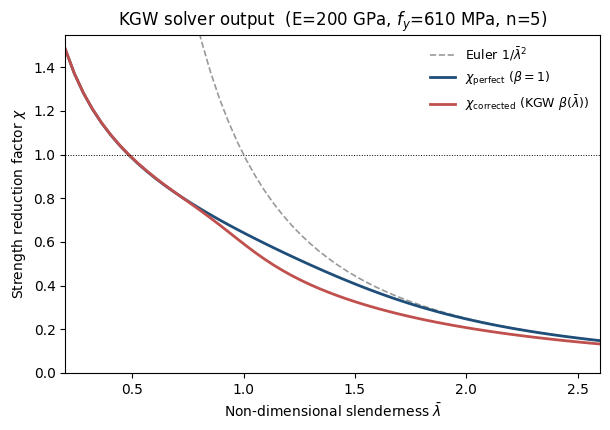

In [2]:
lam = np.linspace(0.2, 2.6, 60)
chi_p = np.array([chi_perfect(l, n, E, fy)   for l in lam])
chi_c = np.array([chi_corrected(l, n, E, fy) for l in lam])

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(lam, 1/lam**2, color="0.6", ls="--", lw=1.2, label=r"Euler $1/\bar\lambda^2$")
ax.plot(lam, chi_p, color="#1f4e79", lw=2.0, label=r"$\chi_{\rm perfect}$ ($\beta=1$)")
ax.plot(lam, chi_c, color="#c0504d", lw=2.0, label=r"$\chi_{\rm corrected}$ (KGW $\beta(\bar\lambda)$)")
ax.axhline(1.0, color="k", lw=0.7, ls=":")
ax.set_xlabel(r"Non-dimensional slenderness $\bar\lambda$")
ax.set_ylabel(r"Strength reduction factor $\chi$")
ax.set_title("KGW solver output  (E=200 GPa, $f_y$=610 MPa, n=5)")
ax.set_ylim(0, 1.55); ax.set_xlim(0.2, 2.6)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## A.6 · Verification result and conclusions

The cell below runs the deterministic verification battery in `src/kgw_verification.py` against `data/validation/kgw_table1.csv` (the full 42-row Table 1). There is no Monte Carlo anywhere in the pipeline; every number is reproducible bit-for-bit. Four checks run in order:

1. **Equation residual** — $\chi_{\text{solver}}$ is substituted back into $g(\chi) = k\chi^{n} + \chi - 1/\bar\lambda^{2}$ for every Table 1 row; $|g| < 10^{-10}$ is asserted. This proves the root-finder converged on the governing equation.
2. **Analytical cross-check ($n=3$)** — for $n=3$ the governing equation is a cubic with a closed-form Cardano root (KGW Appendix); the solver must match the exact root to machine precision across $\bar\lambda \in [0.2, 3.0]$. An independent analytical ground truth that closes the shape-check blind spot to uniform mis-scaling.
3. **Constants** — $\alpha_{\text{RO}} = 0.002$ and the Eq. 19 correction-factor constants $(a_0, a_1, a_2, \bar\lambda_t) = (5, 0.275, 0.725, 0.9)$ are asserted directly, including the identities $a_1 + a_2 = 1$ (stocky asymptote) and $a_2 - a_1 = 0.45$ ($\beta_{\min}$).
4. **Table 1 benchmark** — the area-invariant family check of A.4, reported as per-row kN residuals after the one legitimate per-family scale $\hat{C}_f = \mathrm{median}(P_C^{\text{mod}}/\chi_{\text{solver}})$, together with a **deterministic printed-precision budget** per row (two extra solver calls at $\bar\lambda \pm \tfrac{1}{2}\mathrm{ULP}$, plus the load ULP — this replaces the previous Monte-Carlo "rounding floor").

The figure shows: **(a)** parity of the scaled solver against the published loads; **(b)** signed row residuals vs slenderness with the precision-budget band and the frozen regression guard; **(c)** the per-family residual summary.

In [3]:
from src.kgw_verification import verify

df_val = verify(verbose=True)   # runs the full battery; asserts every check

KGW solver - deterministic verification battery
solver correctness
  1. equation residual (42 rows) : max |g| = 1.79e-11   (tol 1e-10)  PASS
  2. n=3 analytical (Cardano)    : max rel err = 2.47e-13   (tol 1e-09)  PASS
  3. constants                   : ALPHA_RO = 0.002, beta(a0,a1,a2,lt) = (5, 0.275, 0.725, 0.9)  PASS
Table 1 benchmark (area-invariant, per-family scale = median)
  rows / families                : 42 / 11
  pooled shape CoV               : 1.79 %
  max |row residual|             : 5.03 %
  RMS residual                   : 1.86 %
  printed-precision budget       : median 0.45 % (ULP lambda = 0.01, ULP P = 0.1 kN)
  rows within budget             : 17/42
  regression guards              : CoV <= 2.5 %, max resid <= 5.5 %

  reading: checks 1-3 prove the solver solves KGW Eq. 16-17
  correctly. The Table 1 residual beyond the printed-precision
  budget is a systematic within-family drift attributable to
  Table 1 provenance (unrounded inputs unavailable), and is
  reporte

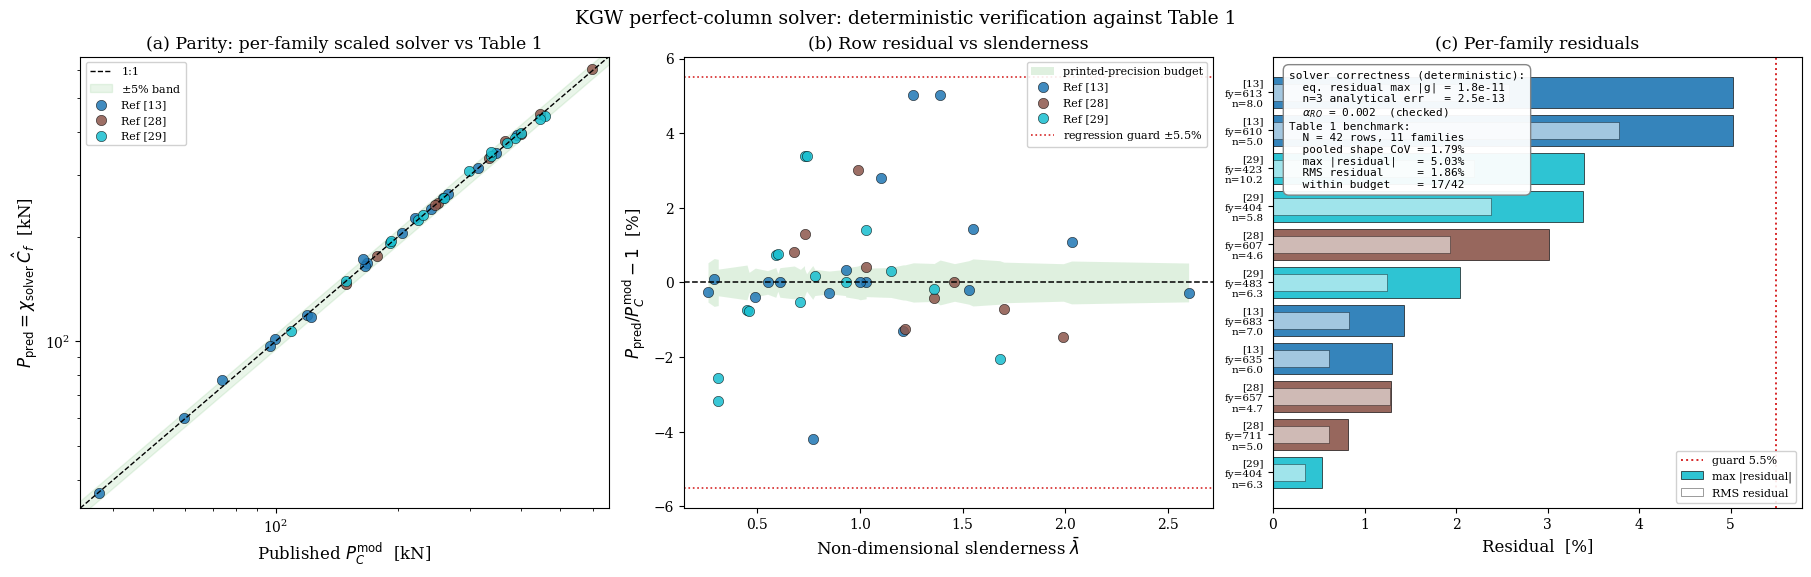

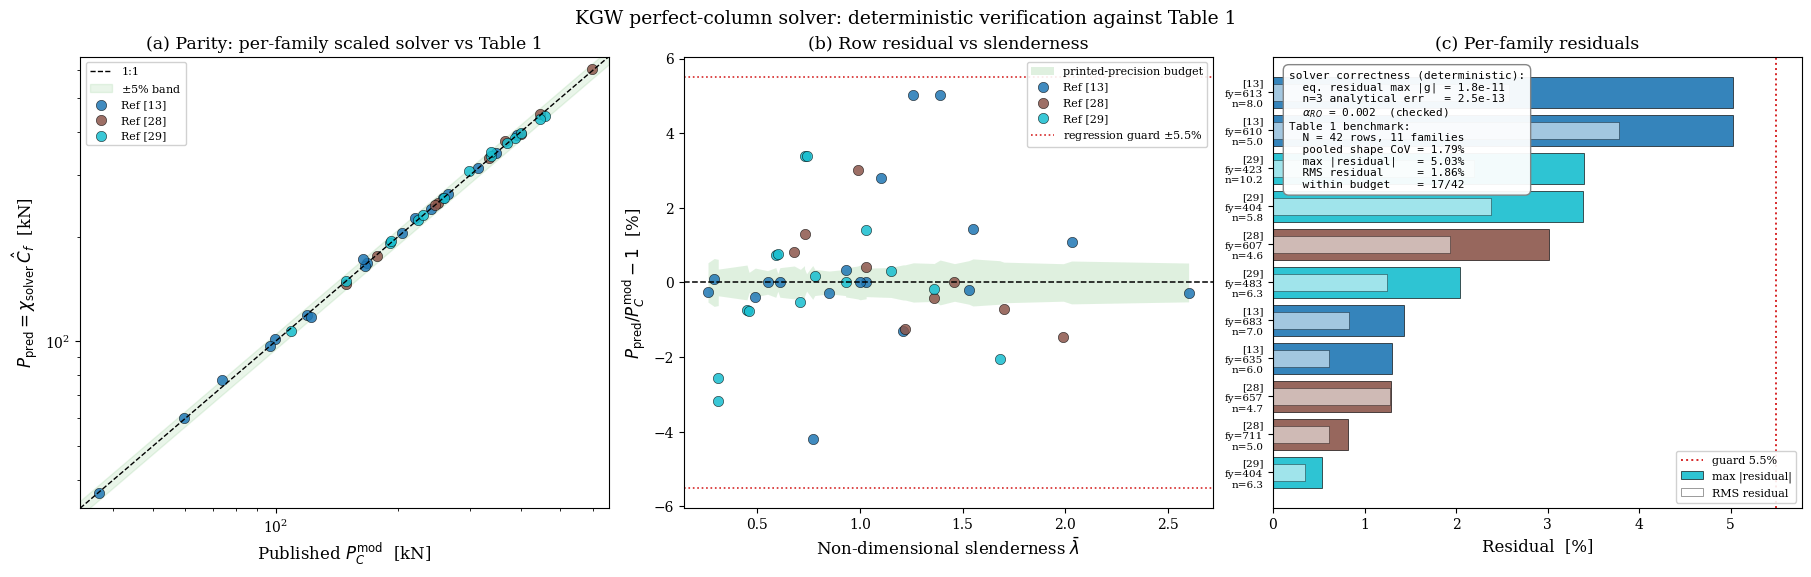

In [4]:
from src.kgw_verification import make_figure

fig = make_figure(df_val)
fig

**Result.**

- **Solver correctness is established deterministically:** maximum equation residual $1.8\times10^{-11}$ across all 42 rows; agreement with the $n=3$ closed-form solution to $2.5\times10^{-13}$; $\alpha_{\text{RO}}$ and all $\beta(\bar\lambda)$ constants match the paper exactly.
- **Table 1 agreement:** pooled within-family shape CoV **1.79 %**, RMS residual **1.86 %**, worst single row **5.03 %**; 17/42 rows fall within the printed-precision budget (median 0.45 %).

**What the residual is — and is not.** An earlier version of this section attributed the scatter to table rounding. The deterministic budget shows that is not tenable: printed precision explains only ≈0.4–0.6 % per row. The remainder is a *systematic within-family drift* of the implied $A f_y$ with slenderness — largest in families $[13]\,|\,f_y{=}610$ and $[13]\,|\,f_y{=}613$ — which correlates with neither printed precision nor the ±0.4 % row-to-row dimension wobble of the specimens. Because checks 1–2 pin the solver to the governing equation exactly, this drift belongs to Table 1 *provenance* (the paper's unrounded $\bar\lambda$ and material inputs are unavailable), not to the solver. It is bounded by frozen regression guards (CoV ≤ 2.5 %, max row residual ≤ 5.5 %) that act as drift alarms for any future change to the solver — they are documented thresholds, not statistical claims.

**Coverage envelope.** Table 1 spans $n = 4.6$–$10.2$, $f_y = 404$–$711$ MPa, $\bar\lambda = 0.26$–$2.60$. Of the 229 `master.csv` specimens, 214 (93 %) fall inside the $\bar\lambda$ range but only 68 (30 %) inside all three ranges simultaneously (the master set spans $n = 3.0$–$9.0$, $f_y = 222$–$757$ MPa). This does not weaken solver *correctness* — the equation-residual and analytical checks hold for any admissible input, and the $n=3$ cross-check sits below the Table 1 $n$-range — but claims of *benchmarked agreement with the published model* extend only over the Table 1 envelope.

**Scope note.** Table 1 verifies the perfect-column path ($\beta = 1$) only. The imperfection-corrected path is covered by the constants asserts alone, which is sufficient for Stage 1/2: the Stage 2 model re-learns the imperfection correction from the experimental data rather than trusting Eq. 19, and any learned correction is re-inserted into the solve (see A.2), never multiplied onto $\chi$.

On this basis the solver is trusted to generate the physics baseline for Stage 1: `chi_perfect` supplies the reference $\chi(\bar\lambda, n, E, f_y)$ for every `master.csv` row, and the verification above is reproducible at any time via `python -m src.kgw_verification`.

# Part B: Batch application of the verified solver to `master.csv`

## B.1 · Execution record

With the solver verified (Part A), the batch stage applies it to every specimen in the master dataset. The implementation and its history:

1. **Module.** `src/kgw_batch.py` exposes a pure function `add_predictions(df)` (no I/O, testable in isolation) plus a CLI entry point (`python -m src.kgw_batch`).
2. **Integration.** The batch runs as the **final stage of `build.py`**, after failure-mode inference and before validation/write-out. This was a deliberate architectural decision: a standalone post-processor would mean the next upstream rebuild silently regenerates `master.csv` *without* the solver columns — the dataset would fork depending on which script ran last. As a build stage, `python build.py` always produces the complete, identical dataset.
3. **Coverage.** Predictions are computed for **all rows with valid inputs**, not only `flexural_scope` rows — scope remains an analysis-time filter, and out-of-scope rows stay inspectable. Current build: **229/229 rows converged**.
4. **Numerical safety (three deterministic layers).** (i) *Pre-validation*: rows with missing or non-positive $\bar\lambda$, $n$, $E_0$, $\sigma_{0.2}$ or $N_{\text{squash}}$ short-circuit to NaN + `kgw_convergence_flag = False` with a logged reason — garbage never reaches the root-finder. (ii) *Guarded solve*: `ValueError` (input guard) and `RuntimeError` (bracket/Brent failure) are caught per row, logged with `specimen_id`, NaN'd — the batch never halts. (iii) *Post-verification*: every converged root is substituted back into the governing equation ($|g| < 10^{-10}$, reusing `kgw_verification.equation_residual` with $m = \beta n$ for the corrected solve), checked against the Euler bound $\chi \le 1/\bar\lambda^2$, and — for $\bar\lambda \ge \bar\lambda_t = 0.9$ — against the ordering $\chi_{\text{kgw}} \le \chi_{\text{perfect}}$ (below the transition the correction legitimately *raises* the load, KGW Fig. 8, so no ordering holds there). Build guard #10 in `build.py` re-validates the prediction columns on every rebuild.

## B.2 · Why these three baselines

- **$\chi_{\text{perfect}}$ ($\beta = 1$)** is the pure physics ceiling: the tangent-modulus bifurcation load of the ideal Ramberg–Osgood column. The gap between experiment and this ceiling *is* the total effect of imperfections — it defines the quantity any correction model must explain.
- **$\chi_{\text{kgw}}$ (Eq. 19 correction)** is the anchor paper's own answer: a correction depending on $\bar\lambda$ **alone**. Whatever scatter survives after this correction is, by construction, variance that a slenderness-only model *cannot* explain — the direct measure of what is left for a richer (Stage 2) model using per-specimen imperfection and material features.
- **$\chi_{\text{eurocode}}$** is the code baseline every proposal must beat to matter in practice. EC3 achieves reliability by being deliberately conservative (design curve below the data), so the comparison of interest is not only mean bias but *scatter*: a model that halves the COV at equal safety enables lighter design.

Predicted loads are $N_i = \chi_i \cdot N_{\text{squash}}$ with $N_{\text{squash}} = A_{\text{eff}} f_y$ for Class 4 — the effective-area basis established in the dataset pipeline flows through automatically. KGW $\chi$ values are uncapped ($\chi > 1$ = strain-hardening reserve); the EC3 curve is capped at 1 per the code. The $\alpha$/$\bar\lambda_0$ mapping (EN 1993-1-4:2006 **Table 5.3**) uses section form, welded/cold basis and buckling axis: 0.49/0.40 for hollow and cold-formed open sections, 0.49/0.20 (major) and 0.76/0.20 (minor) for welded open sections. Grade does not select the curve — it enters only through $f_y$ inside $\bar\lambda$.

In [5]:
import pandas as pd

master = pd.read_csv('../data/master.csv')
conv = int(master['kgw_convergence_flag'].sum())
print(f"rows: {len(master)} | converged: {conv}/{len(master)} | in scope: {int(master['flexural_scope'].sum())}")

for m in ('perfect', 'kgw', 'eurocode'):
    r = master['N_u'] / master[f'N_{m}']
    print(f"  N_exp / N_{m:<9s}: mean = {r.mean():.3f}   COV = {r.std()/r.mean():.3f}")

rows: 229 | converged: 229/229 | in scope: 229
  N_exp / N_perfect  : mean = 1.011   COV = 0.166
  N_exp / N_kgw      : mean = 1.090   COV = 0.168
  N_exp / N_eurocode : mean = 1.104   COV = 0.140


## B.3 · Dataset-wide buckling curves (Figure B1)

One combined plot proved unreadable (8 marker series over 7 curves), so Figure B1 uses **small multiples: one panel per section family**, each showing only the curves that apply to that family — the correct EC3 curve, and the KGW perfect/corrected curves evaluated at that family's *median* material parameters (annotated per panel). Filled markers are Class 1–3; open markers are Class 4 on the $A_{\text{eff}}$ basis. The single most important visual check: **Class 4 points populate the same curves as Class 1–3** — the effective-area basis established upstream has removed the local-buckling penalty from the plotting space, so one buckling curve describes both populations.


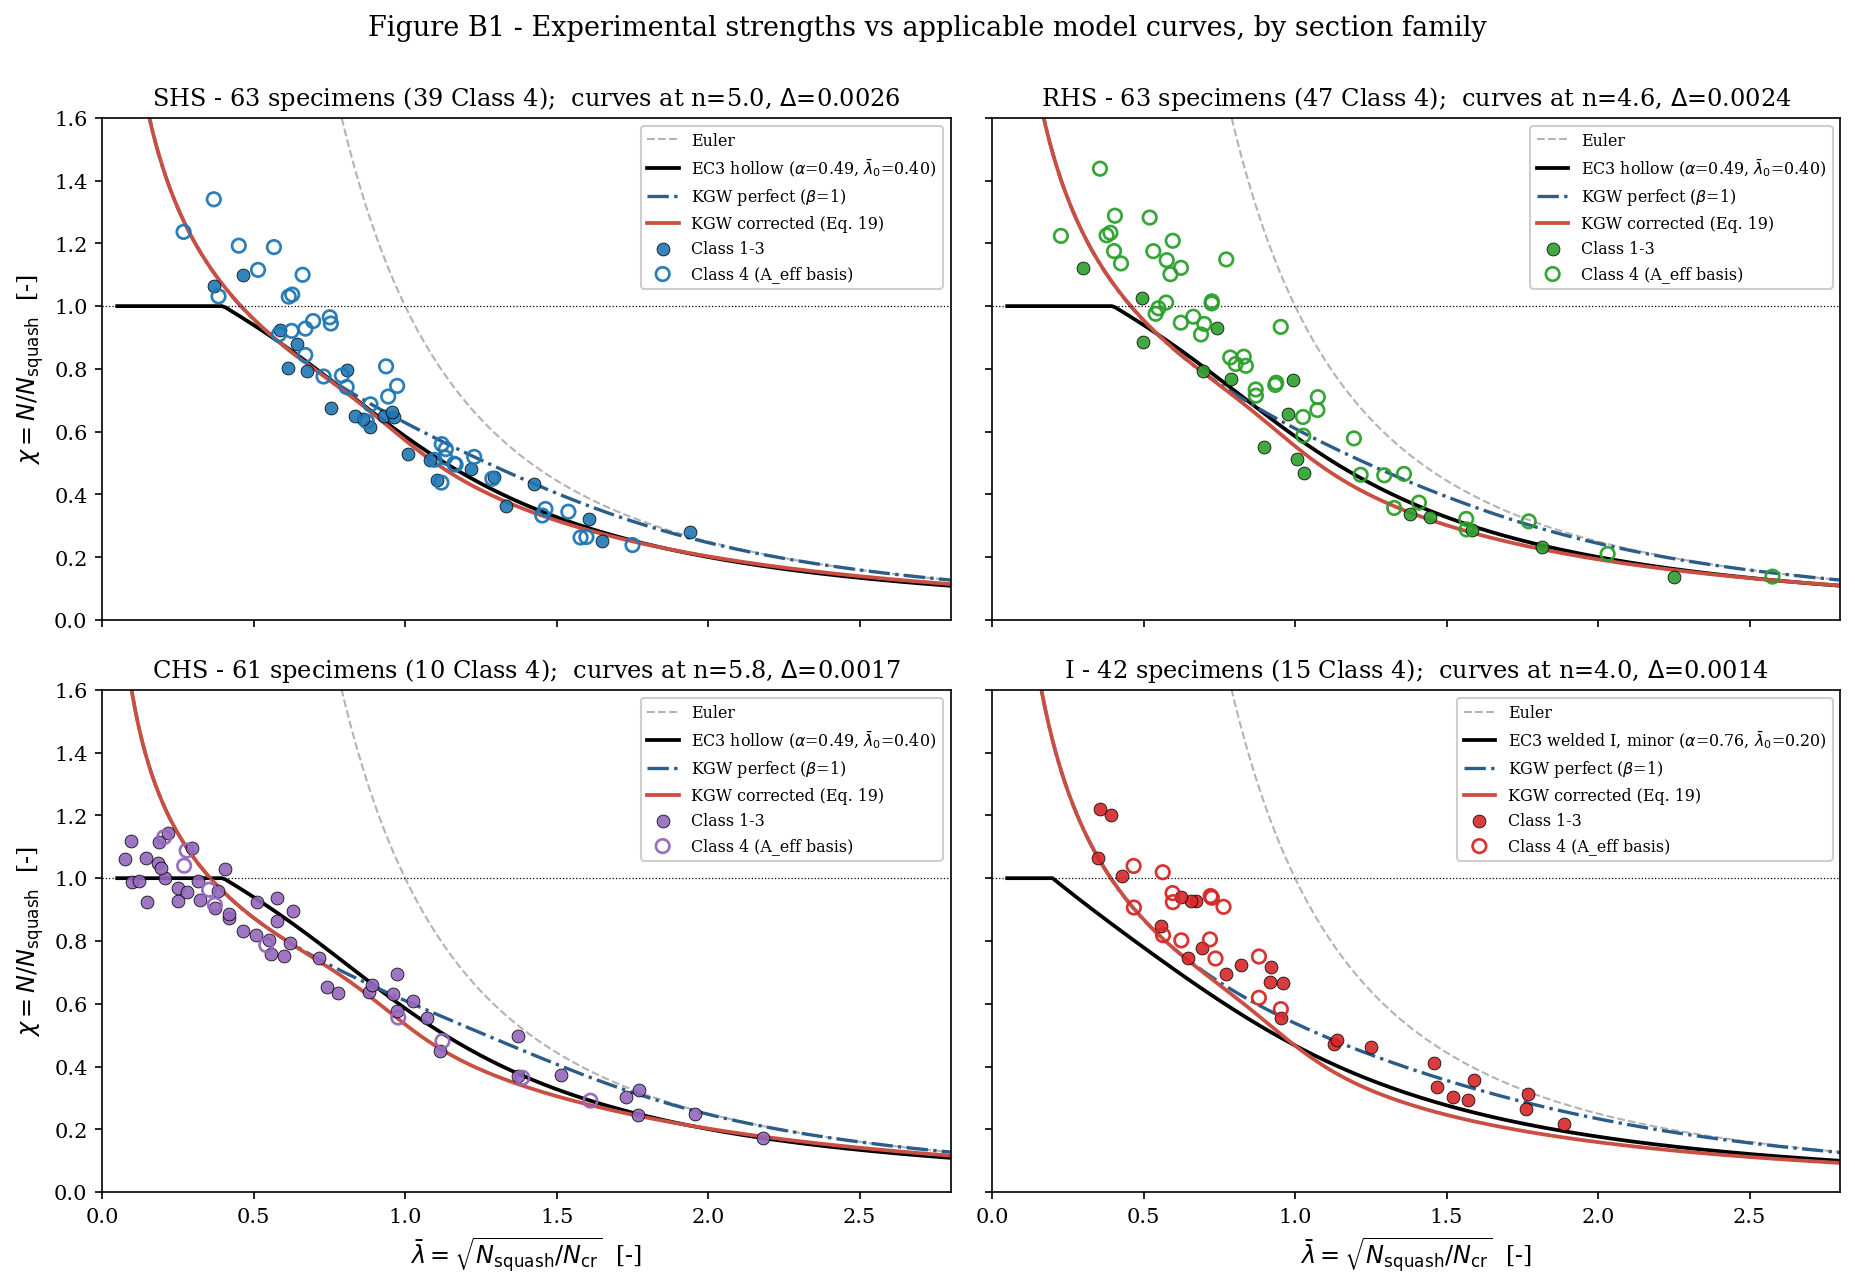

In [6]:
from src.kgw import chi_perfect, chi_corrected
from src.kgw_batch import chi_eurocode as ec3_curve

plt.rcParams.update({'font.family': 'serif', 'font.size': 11,
                     'axes.labelsize': 11.5, 'axes.titlesize': 11.5,
                     'figure.dpi': 150})

FAMS = ['SHS', 'RHS', 'CHS', 'I']
COL = {'SHS': '#1f77b4', 'RHS': '#2ca02c', 'CHS': '#9467bd', 'I': '#d62728'}
lam = np.linspace(0.05, 2.8, 240)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.6), sharex=True, sharey=True)
for ax, fam in zip(axes.flat, FAMS):
    g = master[master['section_type'] == fam]
    n_med, D_med = g['n'].median(), g['Delta'].median()
    E_ref = 200e3; fy_ref = E_ref * D_med

    # reference curves for THIS family only
    ax.plot(lam, 1/lam**2, color='0.7', ls='--', lw=1.0, label='Euler')
    if fam == 'I':
        ax.plot(lam, ec3_curve(lam, 0.76, 0.20), color='black', lw=1.8,
                label=r'EC3 welded I, minor ($\alpha$=0.76, $\bar\lambda_0$=0.20)')
    else:
        ax.plot(lam, ec3_curve(lam, 0.49, 0.40), color='black', lw=1.8,
                label=r'EC3 hollow ($\alpha$=0.49, $\bar\lambda_0$=0.40)')
    ax.plot(lam, [chi_perfect(l, n_med, E_ref, fy_ref) for l in lam],
            color='#2b5d8a', lw=1.6, ls='-.', label=r'KGW perfect ($\beta$=1)')
    ax.plot(lam, [chi_corrected(l, n_med, E_ref, fy_ref) for l in lam],
            color='#c94f42', lw=1.8, label='KGW corrected (Eq. 19)')

    c4 = g['section_class'] == 4
    ax.scatter(g.loc[~c4, 'lambda_bar'], g.loc[~c4, 'chi_exp'], s=38,
               color=COL[fam], edgecolor='k', linewidth=0.4, alpha=0.9,
               label='Class 1-3', zorder=3)
    ax.scatter(g.loc[c4, 'lambda_bar'], g.loc[c4, 'chi_exp'], s=42,
               facecolor='none', edgecolor=COL[fam], linewidth=1.3, alpha=0.95,
               label='Class 4 (A_eff basis)', zorder=3)

    ax.axhline(1.0, color='k', lw=0.6, ls=':')
    ax.set_title(f'{fam} - {len(g)} specimens ({int(c4.sum())} Class 4);  '
                 fr'curves at n={n_med:.1f}, $\Delta$={D_med:.4f}')
    ax.set_xlim(0, 2.8); ax.set_ylim(0, 1.6)
    ax.legend(fontsize=7.6, loc='upper right', framealpha=0.95)

for ax in axes[1]:
    ax.set_xlabel(r'$\bar\lambda = \sqrt{N_{\rm squash}/N_{\rm cr}}$  [-]')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\chi = N/N_{\rm squash}$  [-]')
fig.suptitle('Figure B1 - Experimental strengths vs applicable model curves, by section family',
             fontsize=13, y=0.995)
plt.tight_layout(); plt.show()


## B.4 · Error distributions (Figure B2)

One aligned panel per model, identical bins and axes, so shape shifts read directly. The annotations carry the actionable numbers: mean bias, COV, and the **unconservative fraction** (share of tests weaker than predicted, $N_{\text{exp}}/N_{\text{pred}} < 1$) — the quantity a design-oriented reader checks first.


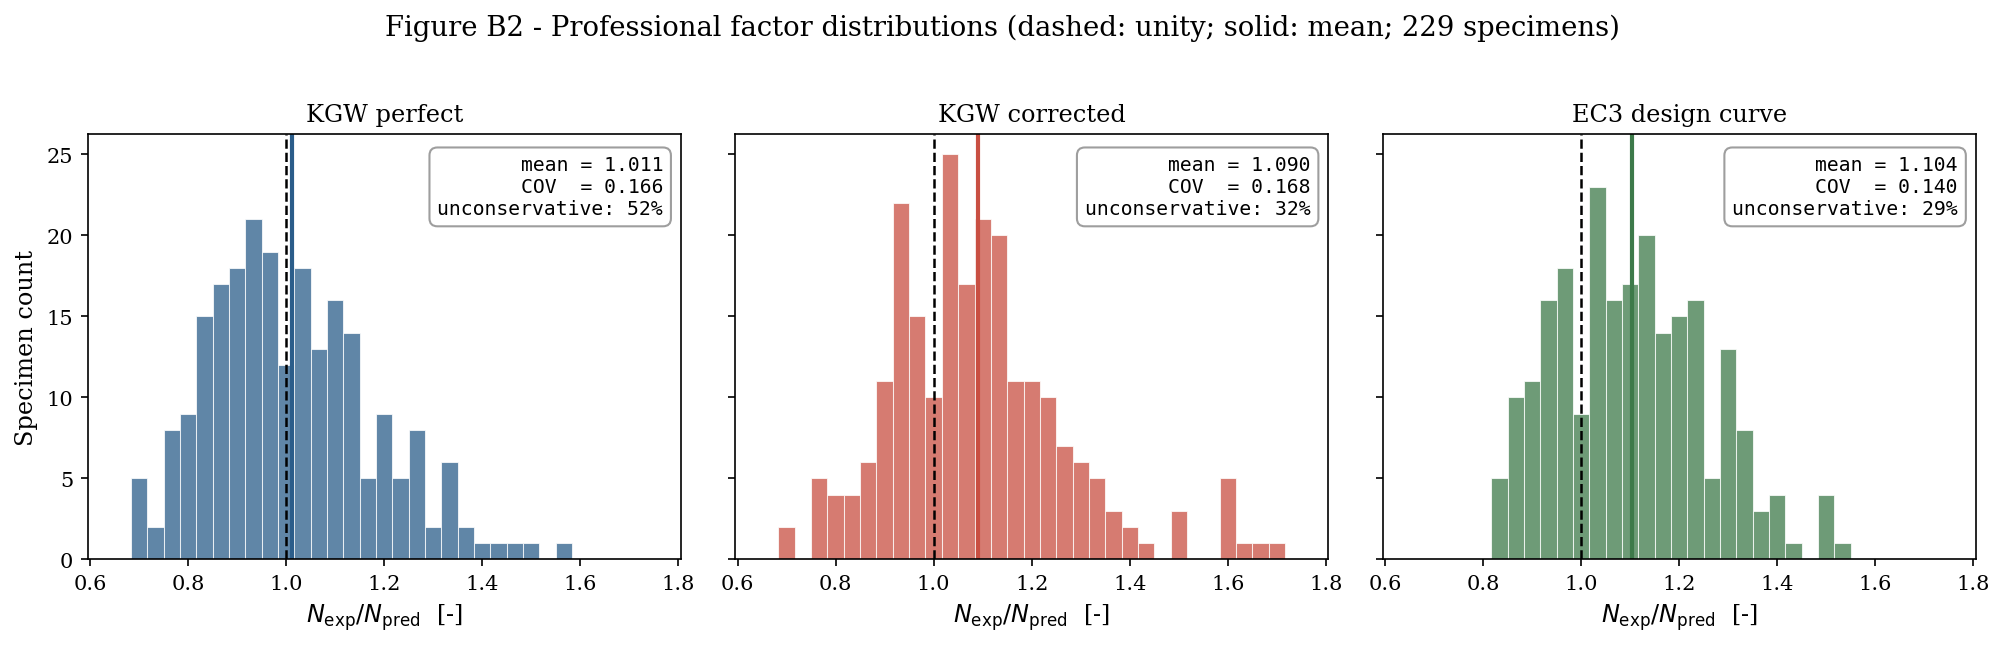

In [7]:
models3 = [('N_perfect', 'KGW perfect', '#2b5d8a'),
           ('N_kgw', 'KGW corrected', '#c94f42'),
           ('N_eurocode', 'EC3 design curve', '#3d7a4a')]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharex=True, sharey=True)
bins = np.linspace(0.65, 1.75, 34)
for ax, (col, name, colr) in zip(axes, models3):
    r = master['N_u'] / master[col]
    ax.hist(r, bins=bins, color=colr, alpha=0.75, edgecolor='white', lw=0.5)
    ax.axvline(1.0, color='black', ls='--', lw=1.2)
    ax.axvline(r.mean(), color=colr, ls='-', lw=2.0)
    unc = 100 * (r < 1).mean()
    ax.set_title(name)
    ax.text(0.97, 0.95,
            f'mean = {r.mean():.3f}\nCOV  = {r.std()/r.mean():.3f}\n'
            f'unconservative: {unc:.0f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='0.6', alpha=0.95))
    ax.set_xlabel(r'$N_{\rm exp}/N_{\rm pred}$  [-]')
axes[0].set_ylabel('Specimen count')
fig.suptitle('Figure B2 - Professional factor distributions '
             '(dashed: unity; solid: mean; 229 specimens)', y=1.02)
plt.tight_layout(); plt.show()


## B.5 · Bias structure vs slenderness (Figure B3)

The same two panels as before, now with the diagnosis made explicit. The KGW panel shows a **systematic unconservative regime below $\bar\lambda \approx 0.4$** (shaded): 72 % of the 36 stocky specimens sit below unity. The cause is structural, not statistical — $\chi_{\text{kgw}}$ is uncapped, but a real stocky column cannot exceed its cross-section resistance, so the uncapped tangent-modulus solution over-predicts exactly where $\chi > 1$. Beyond the plateau the correction settles into a stable conservative offset (≈ +10 %) with per-specimen scatter. EC3, capped at $\chi = 1$, shows no such regime — its residual is flat and featureless, which is what a curve calibrated for uniform safety should look like.


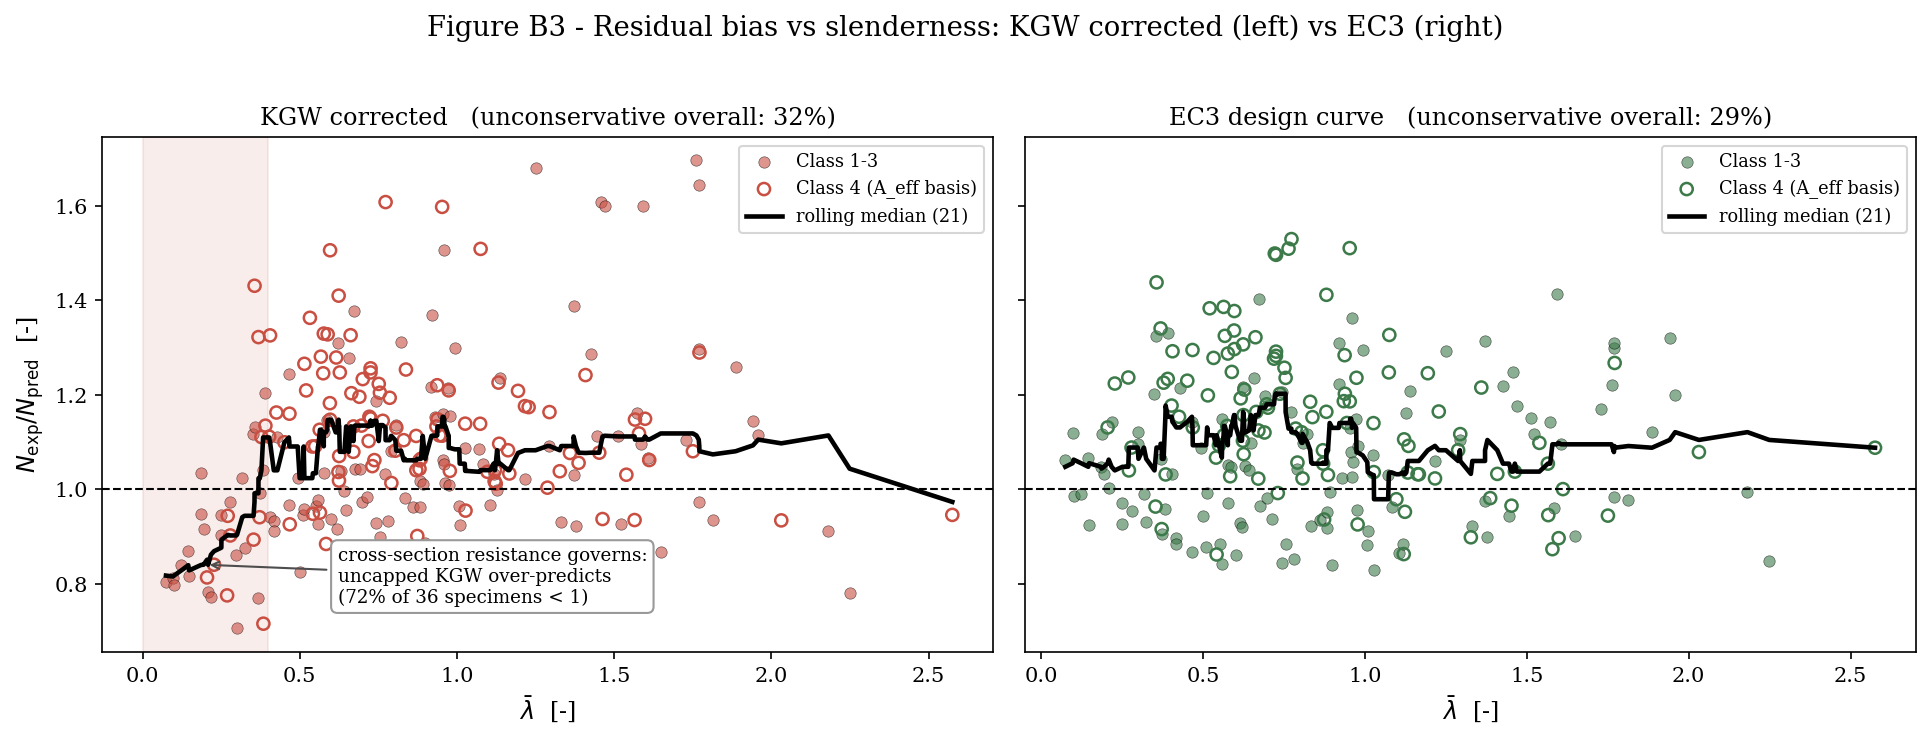

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, (col, name, colr) in zip(axes, [models3[1], models3[2]]):
    r = master['N_u'] / master[col]
    d = pd.DataFrame({'lb': master['lambda_bar'], 'r': r,
                      'c4': master['section_class'] == 4}).sort_values('lb')
    ax.scatter(d.loc[~d.c4, 'lb'], d.loc[~d.c4, 'r'], s=30, color=colr,
               alpha=0.6, edgecolor='k', linewidth=0.3, label='Class 1-3')
    ax.scatter(d.loc[d.c4, 'lb'], d.loc[d.c4, 'r'], s=34, facecolor='none',
               edgecolor=colr, linewidth=1.2, label='Class 4 (A_eff basis)')
    roll = d['r'].rolling(21, center=True, min_periods=7).median()
    ax.plot(d['lb'], roll, color='black', lw=2.2, label='rolling median (21)')
    ax.axhline(1.0, color='k', ls='--', lw=1.0)
    unc = 100 * (r < 1).mean()
    ax.set_title(f'{name}   (unconservative overall: {unc:.0f}%)')
    ax.set_xlabel(r'$\bar\lambda$  [-]')
    ax.legend(fontsize=8.5, loc='upper right')

# annotate the stocky unconservative regime on the KGW panel
ax = axes[0]
ax.axvspan(0.0, 0.4, color='#c94f42', alpha=0.10)
ax.annotate('cross-section resistance governs:\nuncapped KGW over-predicts\n'
            '(72% of 36 specimens < 1)',
            xy=(0.20, 0.84), xytext=(0.62, 0.76), fontsize=8.8,
            arrowprops=dict(arrowstyle='->', lw=1.0, color='0.3'),
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.6'))
axes[0].set_ylabel(r'$N_{\rm exp}/N_{\rm pred}$  [-]')
fig.suptitle('Figure B3 - Residual bias vs slenderness: KGW corrected (left) vs EC3 (right)', y=1.02)
plt.tight_layout(); plt.show()


## B.6 · Where the remaining variance lives (Figure B4)

The scatter surviving the KGW correction is only useful to the project if it is *predictable from measurable features*. Figure B4 ranks the candidate Stage-2 features by their Spearman correlation with the KGW residual. Three findings matter: (i) **cross-section descriptors carry the strongest signal** (`aspect_ratio` $\rho$ = +0.40, `rho_eff` $\rho$ = −0.36) — the slenderness-only correction is blind to section shape; (ii) the **material and imperfection features** (`hardening_ratio` +0.26, `w_total_norm` −0.19) add independent signal, confirming the Stage-2 premise that per-specimen imperfection state should enter the correction; (iii) $\Delta = f_y/E$ shows essentially no residual correlation ($\rho$ = −0.04) — the KGW formulation already absorbs it, so Stage 2 need not re-learn it.


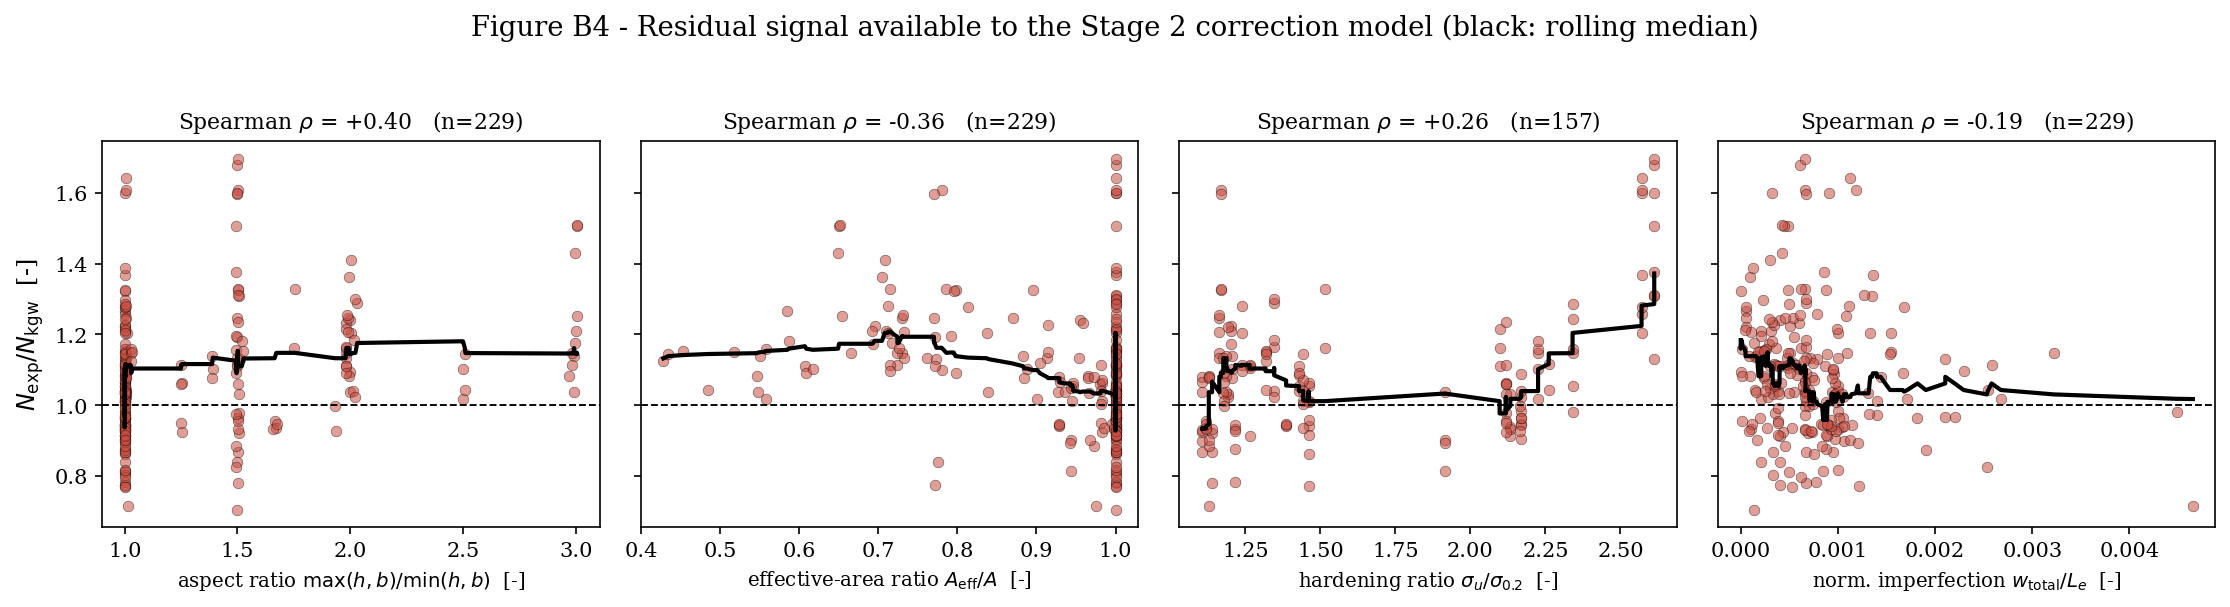

In [9]:
from scipy.stats import spearmanr

feats = [('aspect_ratio', r'aspect ratio $\max(h,b)/\min(h,b)$  [-]'),
         ('rho_eff', r'effective-area ratio $A_{\rm eff}/A$  [-]'),
         ('hardening_ratio', r'hardening ratio $\sigma_u/\sigma_{0.2}$  [-]'),
         ('w_total_norm', r'norm. imperfection $w_{\rm total}/L_e$  [-]')]

r_kgw = master['N_u'] / master['N_kgw']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9), sharey=True)
for ax, (f, xlab) in zip(axes, feats):
    m = master[f].notna() & r_kgw.notna()
    x, y = master.loc[m, f], r_kgw[m]
    rho, p = spearmanr(x, y)
    ax.scatter(x, y, s=26, color='#c94f42', alpha=0.55,
               edgecolor='k', linewidth=0.3)
    d = pd.DataFrame({'x': x, 'y': y}).sort_values('x')
    ax.plot(d['x'], d['y'].rolling(31, center=True, min_periods=10).median(),
            color='black', lw=2.0)
    ax.axhline(1.0, color='k', ls='--', lw=0.9)
    ax.set_xlabel(xlab, fontsize=9.5)
    ax.set_title(fr'Spearman $\rho$ = {rho:+.2f}   (n={int(m.sum())})', fontsize=10.5)
axes[0].set_ylabel(r'$N_{\rm exp}/N_{\rm kgw}$  [-]')
fig.suptitle('Figure B4 - Residual signal available to the Stage 2 correction model '
             '(black: rolling median)', y=1.03)
plt.tight_layout(); plt.show()


In [10]:
rows = []
splits = [('all', master.index == master.index),
          (r'lambda <= 1', master['lambda_bar'] <= 1),
          (r'lambda > 1', master['lambda_bar'] > 1),
          ('Class 1-3', master['section_class'] < 4),
          ('Class 4', master['section_class'] == 4)]
for col, name in [('N_perfect', 'perfect'), ('N_kgw', 'KGW'), ('N_eurocode', 'EC3')]:
    for lab, mask in splits:
        r = (master['N_u'] / master[col])[mask]
        e = (master[col] - master['N_u'])[mask]
        rows.append({'model': name, 'subset': lab, 'n': int(mask.sum()),
                     'mean': round(r.mean(), 3),
                     'COV': round(r.std() / r.mean(), 3),
                     'RMSE [kN]': round(float(np.sqrt((e**2).mean())), 1),
                     'MAPE [%]': round(float((e.abs() / master.loc[mask, 'N_u']).mean() * 100), 2)})
metrics = pd.DataFrame(rows)
print('Table B1 - test-to-prediction statistics (professional factor N_exp/N_pred)')
print(metrics.to_string(index=False))

Table B1 - test-to-prediction statistics (professional factor N_exp/N_pred)
  model      subset   n  mean   COV  RMSE [kN]  MAPE [%]
perfect         all 229 1.011 0.166       74.8     13.34
perfect lambda <= 1 157 1.060 0.156       85.8     12.52
perfect  lambda > 1  72 0.905 0.128       42.1     15.15
perfect   Class 1-3 118 0.963 0.149       83.1     13.05
perfect     Class 4 111 1.062 0.166       64.9     13.65
    KGW         all 229 1.090 0.168       74.3     12.99
    KGW lambda <= 1 157 1.076 0.161       87.8     13.22
    KGW  lambda > 1  72 1.121 0.179       27.1     12.49
    KGW   Class 1-3 118 1.058 0.189       84.0     12.68
    KGW     Class 4 111 1.124 0.138       62.2     13.32
    EC3         all 229 1.104 0.140       82.7     12.51
    EC3 lambda <= 1 157 1.119 0.142       98.0     13.17
    EC3  lambda > 1  72 1.070 0.131       28.5     11.07
    EC3   Class 1-3 118 1.056 0.135       49.7     11.01
    EC3     Class 4 111 1.154 0.131      107.2     14.10


## B.7 · Synthesis — actionable conclusions for the project

**Batch outcome.** 229/229 specimens converged; every root passed the equation-residual, Euler-bound and $\beta$-ordering post-checks. The defensive machinery cost nothing here; its value is that future noisy sources cannot crash the build.

**Model performance** ($N_{\text{exp}}/N_{\text{pred}}$, 229 specimens):

| model | mean | COV | unconservative |
|---|---|---|---|
| KGW perfect ($\beta$ = 1) | 1.011 | 0.166 | 52 % |
| KGW corrected (Eq. 19) | 1.090 | 0.168 | 32 % |
| EC3 design curve | 1.104 | 0.140 | 29 % |

Three conclusions with direct consequences for the next stage:

1. **The Eq. 19 correction re-centres but does not explain.** Mean moves 1.011 → 1.090 while COV is unchanged (0.166 → 0.168): a $\bar\lambda$-only correction cannot address specimen-to-specimen variance. That ≈ 17 % COV is the Stage 2 variance budget, and Figure B4 shows it is not noise — it correlates with section shape ($\rho$ = +0.40 aspect ratio, −0.36 $\rho_{\text{eff}}$), material hardening (+0.26) and imperfection state (−0.19). **Stage 2 should feed exactly these features to the learned correction, and can drop $\Delta$ as a residual predictor ($\rho$ = −0.04).**
2. **The stocky regime needs a resistance cap at *application* time.** Below $\bar\lambda \approx 0.4$, 72 % of specimens fall below the uncapped KGW prediction (Figure B3) — not a solver or data problem, but the physics of cross-section resistance governing before member buckling. Any deployed Stage 2 model should predict the correction *within the solve* and then apply $N \le N_{\text{squash}}$ as a final design bound, mirroring how `chi_exp` is naturally bounded in the tests. `chi_kgw` deliberately stays uncapped in `master.csv` so the ML target retains this information.
3. **The $A_{\text{eff}}$ basis is validated at scale.** Class 4 specimens show *lower* residual scatter than Class 1–3 under KGW (COV 0.138 vs 0.189, Table B1) and populate the same buckling curves in Figure B1. The effective-area pipeline decision has removed what would otherwise be the dominant nuisance variable, roughly doubling the usable training set at no cost in consistency.

On the SHS/RHS subset closest to the anchor paper's own validation, the perfect model gives mean 1.032, COV 0.183 (paper Table 2: 0.975, 0.101 on its 42 curated rows) — consistent once four section families, Class 4 sections and wider material ranges are included. **Hand-off to Stage 2:** target $N_{\text{exp}}/N_{\text{kgw}}$ (or the equivalent in-solve correction), features `aspect_ratio`, `rho_eff`, `hardening_ratio`, `w_total_norm` (plus interactions with $\bar\lambda$), grouped cross-validation by `study_id` to respect the batch structure of material properties.


# Part C — Modelling plan (statement of intent)

Parts A and B established a verified physics baseline and quantified what it leaves unexplained (COV ≈ 0.17 with learnable structure, Figure B4). Part C fixes the rules of the modelling stage *before* any model is fitted: the validation protocol, the metrics, and the model hierarchy. Locking these now is deliberate — on a dataset this small, every protocol choice made after seeing results is a source of optimism.

## C.1 · Train/test and cross-validation strategy

**Why a random split would be invalid here.** The dataset is not 229 independent observations. It is **66 experimental campaigns from 16 source papers** (median 3 specimens per campaign): within a campaign, specimens share the same coupon-measured $f_y$, $E_0$ and $n$, the same nominal cross-section and forming route, and usually the same steel coil — only length and imperfection vary. Concretely, **221 of 229 rows share their exact material fingerprint $(E_0, \sigma_{0.2}, n)$ with at least one sibling row**. Under a random 80/20 split or plain K-fold, siblings land on both sides of the split; a flexible learner can identify the campaign from its fingerprint and recall the campaign's capacity band, inflating apparent accuracy without any genuine generalisation. This is the standard grouped-data leakage failure (Meredig et al. 2018; Durdy et al. 2022; scikit-learn's own GroupKFold guidance), and it is the central threat to validity in this project.

**Protocol (simple, three rules):**

1. **Outer loop — Leave-One-Source-Out (LOSO):** 16 folds, each holding out *all* campaigns of one source paper. Grouping at source level (not just campaign level) is deliberately sterner than the literature default: campaigns within one paper share the test rig, imperfection-measurement convention and lab practice, so campaign-level grouping would still leak paper-level fingerprints. Every specimen receives exactly one **out-of-fold prediction**, and *all* headline metrics are computed on these pooled out-of-fold predictions. With 66 mostly tiny campaigns (15 are single-specimen), pure leave-one-campaign-out would produce unstable single-row folds — the distributional bias documented by Austin, Pe'er & Korem (2025) — which is why the outer unit is the source, not the campaign.
2. **Inner loop — GroupKFold(5) by `study_id`:** all hyperparameter tuning, feature scaling and imputation happen inside the training portion of each outer fold (nested CV), grouped by campaign so tuning cannot exploit leakage either. Preprocessing is fitted on training folds only.
3. **No fixed holdout set.** With 229 rows a single 20 % holdout is just one arbitrary fold with 5× the variance and 20 % less training data; the pooled LOSO out-of-fold predictions *are* the test estimate. As the honesty check, the same models are additionally run under naive random 5-fold CV and the two results reported side by side — **the gap between random-CV and grouped-CV performance is itself a headline result**, quantifying the optimism that leakage would have injected.

**Balance check.** The material families are unevenly represented (austenitic 132, duplex 41, lean duplex 33, ferritic 23), so per-fold metrics will be inspected by family and section class; if any LOSO fold proves degenerate (e.g. the only ferritic source), results are reported with that fold flagged rather than silently averaged away.


In [11]:
# Evidence for the grouping decision: campaign structure and fingerprint duplication
g_study = master.groupby('study_id').size()
g_src = master.groupby('source_id').size()
fp = master.groupby(['E0', 'sigma_02', 'n']).size()

print(f"campaigns (study_id): {len(g_study)}  |  rows/campaign: "
      f"min {g_study.min()}, median {g_study.median():.0f}, max {g_study.max()} "
      f"({(g_study == 1).sum()} singletons)")
print(f"sources (source_id) : {len(g_src)}   |  rows/source:   "
      f"min {g_src.min()}, median {g_src.median():.0f}, max {g_src.max()}")
print(f"rows sharing their exact (E0, sigma_02, n) fingerprint with a sibling: "
      f"{int(fp[fp > 1].sum())}/{len(master)}")
print()
print("LOSO outer-fold sizes (test rows when each source is held out):")
print(g_src.sort_values().to_string())


campaigns (study_id): 66  |  rows/campaign: min 1, median 3, max 10 (15 singletons)
sources (source_id) : 16   |  rows/source:   min 3, median 13, max 34
rows sharing their exact (E0, sigma_02, n) fingerprint with a sibling: 221/229

LOSO outer-fold sizes (test rows when each source is held out):
source_id
ning2021_B         3
ning2021_A         4
liu2003            8
sun2020           10
yuan2015          10
yang2016          12
theofanous2009    12
young2002         12
young2006         14
rasmussen1993     14
afshan2013        15
young2003         16
huang2013         21
gardner2004       22
gardner2016       22
buchanan2018      34


## C.2 · Evaluation metrics

Three tiers, all computed on the pooled LOSO out-of-fold predictions. The engineering tier is decisive; the statistical tier is diagnostic; the reliability tier converts the winner into a design-admissible statement.

**(a) Statistical (diagnostic).**

| metric | definition | what it shows / how to read it |
|---|---|---|
| RMSE [kN] | $\sqrt{\tfrac{1}{N}\sum (N_{\text{pred}} - N_{\text{exp}})^2}$ | Absolute accuracy in load units; penalises large misses (dominated by high-capacity stocky columns). |
| MAE [kN] | $\tfrac{1}{N}\sum \lvert N_{\text{pred}} - N_{\text{exp}} \rvert$ | Robust companion to RMSE; a large RMSE/MAE gap diagnoses heavy-tailed residuals (a few badly-missed specimens). |
| RMSE$_\chi$, MAE$_\chi$ [–] | same, on $\chi = N/N_{\text{squash}}$ | Dimensionless equivalents so stocky (700 kN) and slender (40 kN) specimens weigh comparably — capacities span an order of magnitude, so kN metrics alone over-weight stocky members. |
| R² | pooled out-of-fold | Reported with its caveat attached: under grouped CV a held-out source can lie outside the training envelope and per-fold R² can legitimately go negative — that is the honest signal of extrapolation difficulty, not a bug. Never headline a single R². |

All statistical metrics are reported as **pooled value plus the spread across the 16 LOSO folds** (mean ± SD), never as a single number.

**(b) Structural engineering — the decisive comparison.** The professional factor $r = N_{\text{exp}}/N_{\text{pred}}$, exactly as used in Part B and throughout the stainless steel design literature:

| metric | interpretation |
|---|---|
| mean($r$) | Systematic bias. $>1$: conservative (safe-side); $<1$: over-prediction. Target: marginally above 1.0. **Rejection rule fixed now: mean < 0.97 = systematic over-prediction, recalibrate or reject for design use.** |
| COV($r$) | Scatter — the single most important number. The fixed, parameter-free benchmarks from Part B are: **EC3 0.140** and **KGW 0.168** (mean 1.104 and 1.090 respectively, on identical rows). The ML model earns its place only if its out-of-fold COV is *materially below both*. |
| unconservative fraction | share of specimens with $r < 1$ (Part B: EC3 29 %, KGW 32 %) — the quantity a design reader checks first. |

Because the EC3 and KGW baselines have no fitted parameters, their ratios need no cross-validation; comparing them against the ML model's *out-of-fold* ratios on the same 229 specimens is leakage-free and fair.

**(c) Structural reliability — EN 1990 Annex D.** For the selected model only, the statistical resistance-model procedure:

1. **Correction factor $b$** — least-squares slope of $N_{\text{exp}}$ on $N_{\text{pred}}$: the mean model correction ($b < 1$ means the model over-predicts on average).
2. **Error term $\delta_i = N_{\text{exp},i}/(b\,N_{\text{pred},i})$** and its coefficient of variation $V_\delta$ — the model's *own* scatter after correcting the mean, the quantity Annex D penalises.
3. **Total resistance COV $V_r$** — combines $V_\delta$ with basic-variable variability using the canonical stainless steel statistics of Afshan, Francis, Baddoo & Gardner (2015): material over-strength/COV **1.3/0.060 (austenitic), 1.1/0.030 (duplex), 1.2/0.045 (ferritic)**, geometric COV **0.05**.
4. **Required partial factor $\gamma_M^*$** for target reliability index $\beta = 3.8$ (50-year, CC2; FORM sensitivity $\alpha_R = 0.8$). **Interpretation: the model is design-admissible if $\gamma_M^* \le 1.1$** (the EN 1993-1-4 recommended $\gamma_{M1}$); otherwise the required $\gamma_M^*$ is itself the reported deliverable. Sensitivity of $\gamma_M^*$ to the assumed material statistics and to the lognormal assumption will be stated, since Annex D outcomes are known to be sensitive to both.


## C.3 · Targets, features and candidate models

**Target.** The primary target is the dimensionless residual ratio
$$r = \chi_{\text{exp}}/\chi_{\text{kgw}} \;\left(= N_{\text{exp}}/N_{\text{kgw}}\right),$$
i.e. the models learn the *correction to the verified physics baseline*, not the capacity from scratch. This has three advantages on a 229-row dataset: the physics (Euler limit, material nonlinearity, slenderness dependence) is already encoded, so the ML problem shrinks to explaining a bounded ratio near 1; the target is campaign-agnostic and dimensionless, attacking fingerprint leakage at the source; and the final prediction $\hat N = \hat r \cdot N_{\text{kgw}}$, capped at $N_{\text{squash}}$ (the Part B stocky-regime rule), degrades gracefully to the KGW baseline when a model abstains. For the symbolic-regression track only, the physics-native alternative target — the in-solve correction $\beta_{\text{exp}}$ back-solved through `kgw.py` — will also be explored, since Part A showed a learned correction is properly re-inserted inside the solve rather than multiplied onto $\chi$.

**Features** — fixed a priori from the Figure B4 evidence and physical reasoning, in campaign-agnostic non-dimensional form:

| feature | role | evidence (Spearman ρ vs residual) |
|---|---|---|
| `lambda_bar` | interaction axis — where the correction acts | +0.26 (and the B3 trend) |
| `aspect_ratio` | section shape, invisible to KGW | **+0.40** (strongest single signal) |
| `rho_eff` | local slenderness / A_eff reduction | **−0.36** |
| `hardening_ratio` | strain-hardening reserve | +0.26 (157/229 rows; missing values handled natively by tree models, median-imputed *within training folds* elsewhere) |
| `w_total_norm` | measured imperfection state | −0.19 |
| `n` | Ramberg–Osgood exponent | −0.19 |
| `section_type`, `material_type` | categoricals for tree models | — |

$\Delta = f_y/E$ is **excluded** as a residual predictor (ρ = −0.04): the KGW formulation already absorbs it, and re-admitting it would mostly re-encode campaign identity.

**Candidate models** — a deliberately short hierarchy, simplest first, following the small-tabular-data evidence (Grinsztajn et al. 2022: tree ensembles beat deep learning well beyond this data size):

1. **Elastic-net linear regression** on the features above — the disciplined baseline. If a penalised linear model matches the ensembles, that is itself a finding about the sufficiency of the KGW feature basis.
2. **Gradient-boosted trees** (XGBoost or CatBoost; shallow trees, early stopping, tuned in the inner grouped loop) — the non-linear workhorse, with **SHAP** interpretation checked for physical consistency (capacity ratio should fall with imperfection, rise with hardening) as a sanity gate. Known limitation to report: trees extrapolate as constants beyond the training envelope.
3. **Gaussian process regression, Matérn ν = 5/2 kernel** on standardised features — comparable point accuracy expected, plus principled epistemic uncertainty that grows for held-out sources far from the training data: exactly the input the Annex D reliability step and any "trust region" statement need. (Matérn over RBF because infinitely-smooth kernels are unrealistic for physical responses — Rasmussen & Williams 2006, §4.2.1.)
4. **Symbolic regression (PySR)**, operator set seeded with the KGW non-dimensional groups — the design-oriented deliverable: a closed-form, hand-computable correction directly comparable to Eq. 19 and adoptable in code format. Complexity constrained via the Pareto front and validated under the same LOSO protocol.

Deep networks are *not* part of the core hierarchy at N = 229 (a small regularised MLP may be run for completeness; a KGW-constrained PINN is noted as exploratory future work, defensible only because the energy formulation supplies a physics residual). **Model selection rule, fixed now:** adopt the *simplest* model whose out-of-fold COV($r$) is within one standard error of the best, preferring models that quantify uncertainty. Success for the stage overall means beating both fixed benchmarks — COV below 0.140 (EC3) with mean $r \ge 1.0$ — under leakage-free LOSO validation; anything less is reported as a negative result, not tuned away.
